# EDA временного ряда <a class="tocSkip">

При подготовке к прогнозированию ВР важно проверить наличие:

    1. Тренда
    2. Сезонности
    3. Резкого изменения поведения в вр
    4. Выбросов

В этом ноутбуке мы рассмотрим различные примеры нестационарных рядов, а также способы приведения исходного нестационарного ряда к стационарному. Основные причины нестационарности приведены на рисунке ниже:

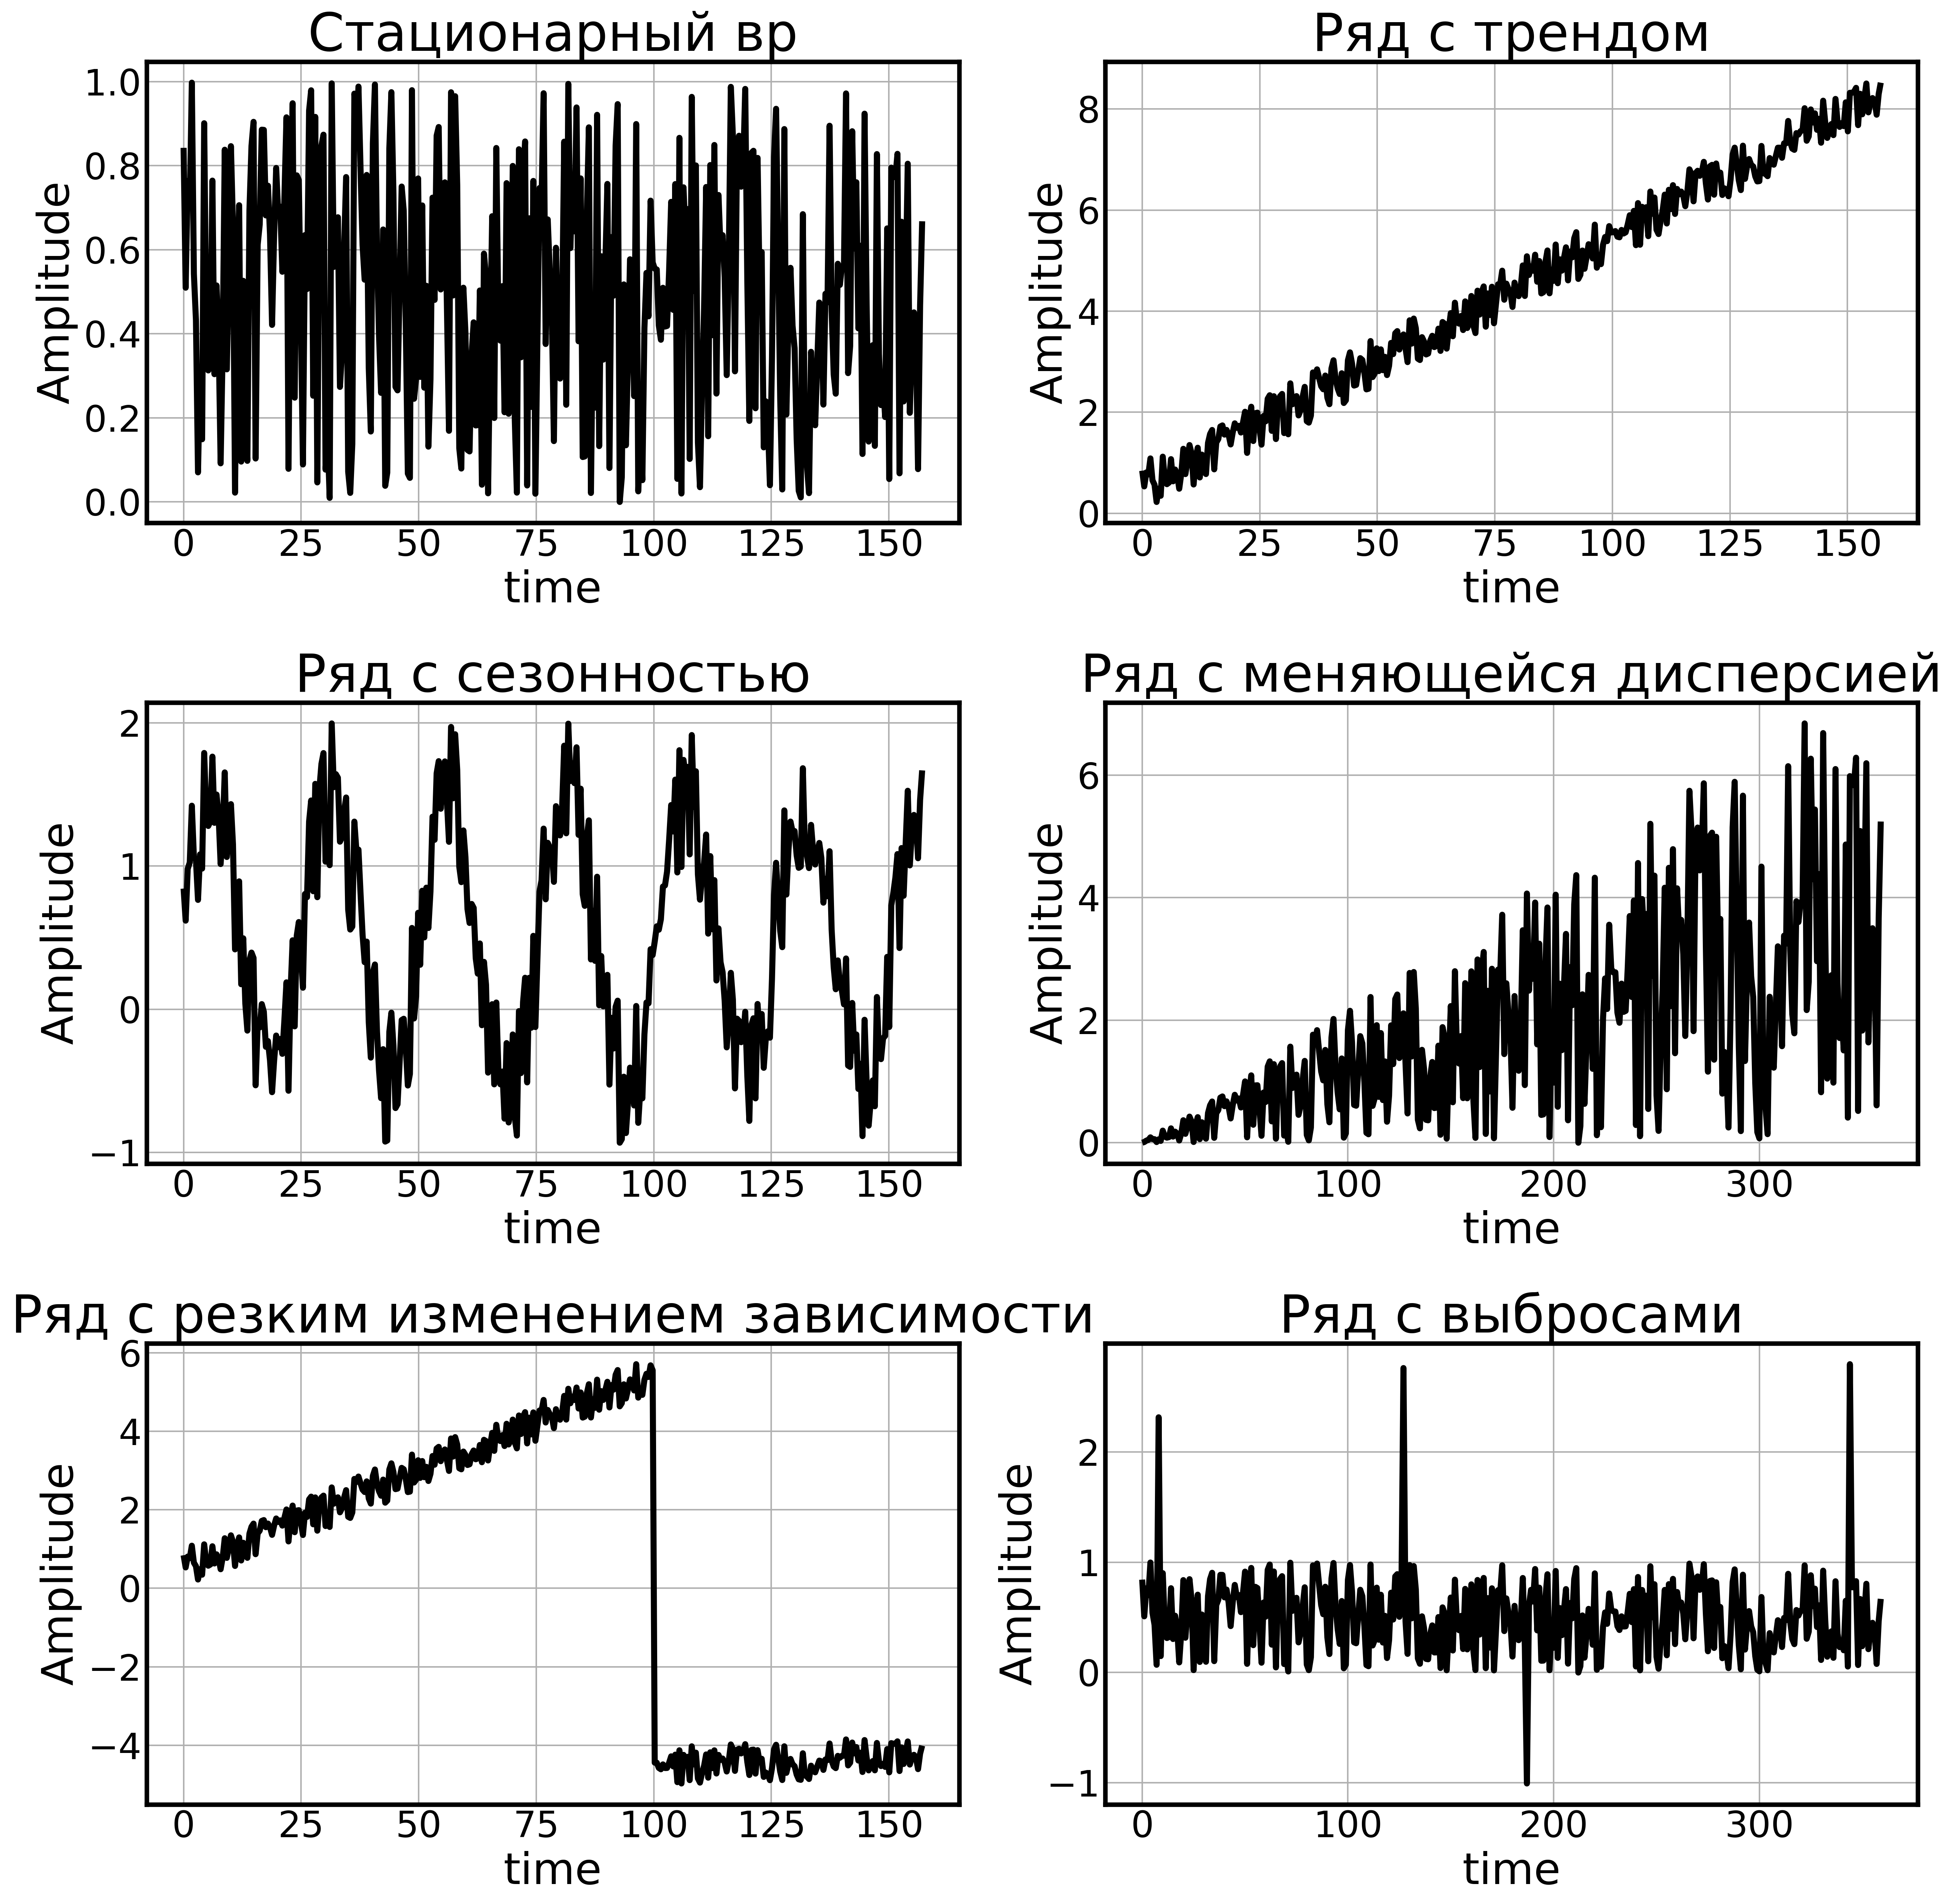

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")
import statsmodels.api as sm
from scipy import stats

In [ ]:
params = {'lines.linewidth': 4,
          'lines.solid_capstyle': 'butt',
          'axes.labelsize': 'large',
          'axes.axisbelow': True,
          'axes.grid': True,
          'axes.linewidth': 3.0,
          'axes.titlesize': 'x-large',
          'grid.linestyle': '-',
          'grid.linewidth': 1.0,
          'xtick.major.size': 0,
          'xtick.minor.size': 0,
          'ytick.major.size': 0,
          'ytick.minor.size': 0,
          'figure.subplot.left': 0.08,
          'figure.subplot.right': 0.95,
          'figure.subplot.bottom': 0.07,
          'figure.figsize': (10.8, 7.8),
          'figure.autolayout': True,
          'figure.dpi': 300,
          'font.size': 24.0 }
plt.rcParams.update(params)

In [ ]:
pd.options.display.max_rows = 999

In [ ]:
%cd ..
%cd ..
%env PYTHONPATH=.

# Визуальный анализ ряда

Самый первый шаг, который рекомендуется сделать - это провести визуальный анализ ВР. 

## ВВП России

In [ ]:
gdp = pd.read_csv("data/russia-gdp-gross-domestic-product.csv")

In [ ]:
gdp.head()

In [ ]:
gdp['date'] = pd.to_datetime(gdp['date'])
gdp.set_index('date',inplace=True) # задаем дату в качестве индекса

In [ ]:
ax = gdp.plot(y=' GDP ( Billions of US $)', legend=False,marker='o')
ax.set_ylabel('Russian GDP (Billions of US $)')
ax1 = ax.twinx()
ax.set_xlabel('Year')
plt.xticks(rotation=90);

## Солнечные пятна

In [ ]:
Sun = pd.read_csv('data/sun.csv')
Sun['YEAR'] = pd.to_datetime(Sun['YEAR'].astype(int).astype(str) + '-01-01')
Sun.set_index("YEAR",inplace=True)

In [ ]:
Sun.tail()

In [ ]:
ax = Sun.plot( legend=False)
ax.set_ylabel('Sun spot activity')
ax.set_xlabel('Year');

In [ ]:
ax = Sun.iloc[:51,:].plot()
ax.set_ylabel('Sun spot activity')
ax.set_xlabel('Year');

## Кол-во пассажиров на международных рейсах

## Количество пассажиров на международных рейсах

In [ ]:
airline = pd.read_csv('data/international-airline-passengers.csv', sep=';')
airline['Month'] = pd.to_datetime(airline['Month']+'-01')
airline.set_index('Month', inplace=True)

In [ ]:
airline.head()

In [ ]:
fig, ax = plt.subplots(1, 1)
ax.plot(airline.index, airline['Passengers'])
ax.set_xlabel('Date')
ax.set_ylabel('Passengers');

## Температурные данные - гора Вашингтон, Нью-Хэмпшир

Содержит ежедневные минимальные температуры по сухому термометру (F), зарегистрированные на вершине горы Вашингтон за четыре года с 1 декабря 2014 по 30 ноября 2018.

## Температурные данные – гора Вашингтон, Нью-Хэмпшир

Содержит ежедневные минимальные температуры по сухому термометру (°F), зарегистрированные на вершине горы Вашингтон в Нью-Гэмпшире за четыре года с 1 декабря 2014 г. по 30 ноября 2018 г. 

In [ ]:
temps = pd.read_csv('data/MtWashingtonDailyTemps.csv',index_col='DATE',parse_dates=True)
temps.index.freq = 'D'
temps.head()

In [ ]:
temps['AvgTemp'].plot(figsize=(12,5));

In [ ]:
temps.iloc[:90,:]['AvgTemp'].plot(figsize=(12,5));

## Среднегодовой сток реки Рейн около Базеля, Швейцария 1807-1957 г.г. (150 записей)

## Среднегодовой сток реки Рейн около Базеля, Швейцария, 1807–1957 гг. (150 записей)

In [ ]:
river = pd.read_csv('data/rhine_river_discharge.csv',index_col='Year',parse_dates=True)
river.index.freq = 'AS'
river.head()

In [ ]:
title = 'Rhine River Mean Annual Discharge'
ylabel='Discharge (m³/s)'
xlabel='' # we don't really need a label here

ax = river['Discharge'].plot(figsize=(12,5),title=title)
ax.autoscale(axis='x',tight=True)
ax.set(xlabel=xlabel, ylabel=ylabel);

## Объем поставок производителей обрабытывающей промышленности

Объем отгрузок производитедей для всех отраслей обрабатывающей промышленности в миллионах долларов без учета сезонных колебаний. Ежемесячные данные с января 1992 г. по январь 2019 г. (325 записей)

## Объем поставок производителей

Объем отгрузок производителей для всех отраслей обрабатывающей промышленности в миллионах долларов без учета сезонных колебаний. Ежемесячные данные с января 1992 г. по январь 2019 г. (325 записей).

In [ ]:
shipment = pd.read_csv('data/UMTMVS.csv',index_col='DATE',parse_dates=True)
shipment.index.freq = 'MS'
shipment.head()

In [ ]:
import matplotlib.ticker as ticker
formatter = ticker.StrMethodFormatter('{x:,.0f}')

title="Value of Manufacturers' Shipments" 
ylabel='Millions of Dollars'
xlabel='' 

ax = shipment['UMTMVS'].plot(figsize=(12,5),title=title)
ax.autoscale(axis='x',tight=True)
ax.set(xlabel=xlabel, ylabel=ylabel)
ax.yaxis.set_major_formatter(formatter);

In [ ]:
shipment.iloc[:36,:]['UMTMVS'].plot(figsize=(12,5),title=title)

## Продажи товаров салонов сотовой связи

In [ ]:
df_items = pd.read_csv("data/example_dataset.csv",index_col='timestamp',parse_dates=True)

In [ ]:
sales = df_items.pivot_table(index=df_items.index, columns='segment',values='target')

In [ ]:
sales.head()

In [ ]:
title = 'Item shop sales'
ylabel='Items'
xlabel='' # we don't really need a label here

ax = sales['segment_c'].plot(figsize=(12,5),title=title)
ax.autoscale(axis='x',tight=True)
ax.set(xlabel=xlabel, ylabel=ylabel);
plt.ylim(50,350)

In [ ]:
title = 'Item shop sales'
ylabel='Items'
xlabel='' # we don't really need a label here

ax = sales['segment_c'].iloc[:14].plot(figsize=(12,5),title=title)
ax.autoscale(axis='x',tight=True)
ax.set(xlabel=xlabel, ylabel=ylabel);
plt.ylim(50,350)

# Инструменты выделения тренда

В этом разделе мы тестим различные варианты приведения временного ряда к стационарному на примере графика российского ВВП, который имеет довольно сложный нелинейный тренд

## Об экономических циклах

In [ ]:
gdp = pd.read_csv("data/russia-gdp-gross-domestic-product.csv")

In [ ]:
gdp['obs_num'] = gdp.reset_index()['index'] # переменная х для линейного тренда
gdp['date'] = pd.to_datetime(gdp['date'])
gdp.set_index('date',inplace=True) # задаем дату в качестве индекса
gdp['const'] = 1 # свободный член для линейного тренда

In [ ]:
gdp.head()

In [ ]:
linear_trend_model = sm.OLS(gdp[' GDP ( Billions of US $)'],gdp[['obs_num','const']]).fit()

In [ ]:
gdp['GDP TREND'] = linear_trend_model.predict(gdp[['obs_num','const']])

In [ ]:
ax = gdp.plot(y=' GDP ( Billions of US $)', legend=False,marker='o')
gdp.plot(y='GDP TREND', legend=False,ax=ax,c='red')
ax.set_ylabel('Russian GDP ( Billions of $)')
ax.set_xlabel('Year')
plt.axvline(['1997-12-31'],c='black',linestyle='--')
plt.axvline(['2008-12-31'],c='black',linestyle='--')
plt.axvline(['2014-12-31'],c='black',linestyle='--')
plt.axvline(['2020-12-31'],c='black',linestyle='--')
plt.xticks(rotation=90);

## Приведение ряда к стационарному с помощью линейного тренда

### Построение детерменированной модели тренда: 

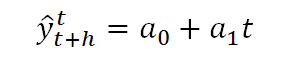

In [ ]:
from scipy import signal
gdp[' GDP ( Billions of US $) detrend'] = signal.detrend(gdp[' GDP ( Billions of US $)'])

### Дифференцирование - Переход к попарным разностям (попарным отношениям) соседних значений

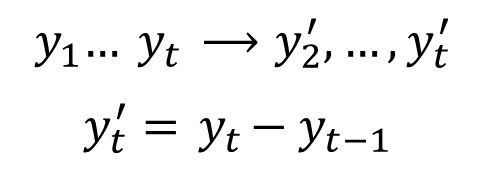
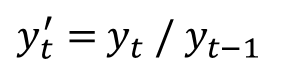

In [ ]:
gdp[' GDP ( Billions of US $) diff'] = gdp[' GDP ( Billions of US $)'] - gdp[' GDP ( Billions of US $)'].shift(1)
gdp[' GDP ( Billions of US $) rel'] = gdp[' GDP ( Billions of US $)']/gdp[' GDP ( Billions of US $)'].shift(1) - 1

### Сглаживанием исходного ряда скользящим средним:

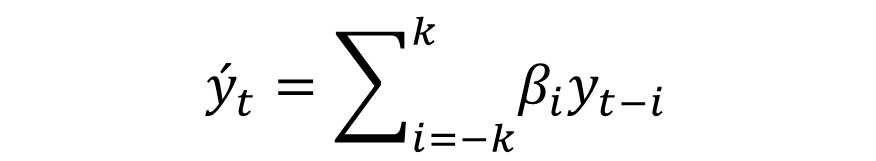

In [ ]:
gdp[' GDP ( Billions of US $) smoothed'] = gdp[' GDP ( Billions of US $)'].rolling(5,center=True).mean()
gdp[' GDP ( Billions of US $) desmoothed'] = gdp[' GDP ( Billions of US $)'] - gdp[' GDP ( Billions of US $) smoothed']

In [ ]:
fig,ax = plt.subplots(4,1,figsize= (15,15)) 
gdp.plot(y=' GDP ( Billions of US $) detrend', legend=False,ax=ax[0])

gdp.plot(y=' GDP ( Billions of US $) diff', legend=False,ax=ax[1])
gdp.plot(y=' GDP ( Billions of US $) rel', legend=False,ax=ax[2])
gdp.plot(y=' GDP ( Billions of US $) desmoothed', legend=False,ax=ax[3]);

In [ ]:
print(np.mean(gdp[' GDP ( Billions of US $) detrend']),np.std(gdp[' GDP ( Billions of US $) detrend']))
print(np.mean(gdp[' GDP ( Billions of US $) diff']),np.std(gdp[' GDP ( Billions of US $) diff']))
print(np.mean(gdp[' GDP ( Billions of US $) rel']),np.std(gdp[' GDP ( Billions of US $) rel']))
print(np.mean(gdp[' GDP ( Billions of US $) desmoothed']),np.std(gdp[' GDP ( Billions of US $) desmoothed']))

In [ ]:
gdp[' GDP ( Billions of US $) smoothed']

## Дополнительные инструменты выделения тренда

### Фильтр Ходрика-Прескотта

Фильтр Ходрика-Прескотта разделяет $y_t$ временного ряда на тренд $\tau_t$ и остаточный цикл $\zeta_t$

$y_t = \tau_t +\zeta_t $

Компоненты определяются путем минимизации следующей квадратичной функции потерь:

$min_{\tau_t} \sum^T_t \zeta^2_t  + \lambda \sum^T_t [(\tau_t - \tau_{t-1}) - (\tau_{t-1} - \tau_{t-2})]^2$

Фильтр Ходрика-Прескотта разделяет $y_t$ временного ряда на тренд $\tau_t$  и остаточный цикл $\zeta_t$,
    $$y_t = \tau_t + \zeta_t$$
Компоненты определяются путем минимизации следующей квадратичной функции потерь:
    $$\min_{\\{ \tau_{t}\\} }\sum_{t}^{T}\zeta_{t}^{2}+\lambda\sum_{t=1}^{T}\left[\left(\tau_{t}-\tau_{t-1}\right)-\left(\tau_{t-1}-\tau_{t-2}\right)\right]^{2}$$

In [ ]:
cycle, trend = sm.tsa.filters.hpfilter(gdp[' GDP ( Billions of US $)'],lamb= 120.25)

In [ ]:
cycle.plot(c='blue',label='cycle')
trend.plot(c='red',label='trend')
gdp[' GDP ( Billions of US $)'].plot(c='green',label='raw series')
plt.legend();

### Сигмоидный тренд с насыщением

Сигмоидная модель моделирует тренд с насыщением. Попробуем обучить такую модель на наших данных с центром в середине ряда

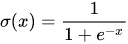

In [ ]:
gdp['obs_num_sigm'] = 1/(1.+np.exp(-1*(gdp['obs_num']-18)))

In [ ]:
linear_trend_model = sm.OLS(gdp[' GDP ( Billions of US $)'],gdp[['obs_num_sigm','const']]).fit()

In [ ]:
gdp['GDP TREND SIGMOID'] = linear_trend_model.predict(gdp[['obs_num_sigm','const']])

In [ ]:
ax = gdp.plot(y=' GDP ( Billions of US $)', legend=False,marker='o')
gdp.plot(y='GDP TREND SIGMOID', legend=False,ax=ax)
ax.set_ylabel('Russian GDP ( Billions of US $')
ax.set_xlabel('Year')
plt.xticks(rotation=90);

### Кусочно-линейный тренд

Одна из наиболее удачных моделей для оценки тренда - кусочно-линейная. Идея простая: разбиваем исходный ряд на несколько отрезков, где сильно поменялась зависимость, и внутри каждого отрезка обучаем простую линейную регрессию

In [ ]:
detrended_piecewise = signal.detrend(gdp[' GDP ( Billions of US $)'],bp=[15,24,30])
gdp['GDP TREND PIECE_LIN'] = gdp[' GDP ( Billions of US $)'] - detrended_piecewise

In [ ]:
ax = gdp.plot(y=' GDP ( Billions of US $)', legend=False,marker='o')
gdp.plot(y='GDP TREND PIECE_LIN', legend=False,ax=ax)
ax.set_ylabel('Russian GDP ( Billions of US $')
ax.set_xlabel('Year')
plt.xticks(rotation=90);

### Сравнение полученных трендов

Сначала оценим результат визуально - построим графики трендов (левый столбец) и остатков (правый столбец)

In [ ]:
N_COLS = 2
trends_list = [gdp['GDP TREND'],
                gdp['GDP TREND PIECE_LIN'],
               gdp['GDP TREND SIGMOID'],
               gdp[' GDP ( Billions of US $) smoothed'],
               trend]

fig,ax = plt.subplots(len(trends_list)+1,N_COLS,figsize=(15,20))

for i,trend_est in enumerate(trends_list):
    gdp.plot(y=' GDP ( Billions of US $)', legend=False,marker='o',label='gdp',ax=ax[i][0])
    trend_est.plot(ax=ax[i][0])
    
    (gdp[' GDP ( Billions of US $)'] - trend_est).plot(ax=ax[i][1])

    
(gdp[' GDP ( Billions of US $) diff']).plot(ax=ax[len(trends_list)][0])
(gdp[' GDP ( Billions of US $) rel']).plot(ax=ax[len(trends_list)][1])

Если смотреть на графики остатков, то лучше всего с операцией детрендирования справляется операция дифференцирования отношением (самый нижний график), т.к. для остальных алгоритмов остатки имеют более выраженную гетероскедастичность - дисперсия остатков растет со временем


Сравним прогноз по моделям тренда с фактами

In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score,mean_squared_error, mean_squared_log_error

In [ ]:
metrics = [mean_absolute_error, r2_score,mean_squared_error, mean_squared_log_error]

In [ ]:
cm = sns.light_palette("green", as_cmap=True,reverse=True,)
error_df = pd.DataFrame([[metr(gdp[tren.notna()][' GDP ( Billions of US $)'],
       tren[tren.notna()]) for metr in metrics] for tren in trends_list],
            index=[tren.name for tren in trends_list],
            columns=[metr.__name__ for metr in metrics])

error_df.style.background_gradient(cmap=cm)

Лучшее качество показывает кусочно-линейный тренд с 3 точками излома. Но тут нужно быть аккуратнее - большое кол-во точек излома ведет к переобучению

Также оценим остатки на стационарность по критериям дики-фуллера и кпсс

In [ ]:
from statsmodels. tsa.stattools import adfuller, kpss

In [ ]:
stattests = [adfuller,kpss]

In [ ]:
stattests = [adfuller,kpss]
remains =   [(gdp[' GDP ( Billions of US $)'] - trend_est).dropna()
              for trend_est in trends_list] + \
            [gdp[' GDP ( Billions of US $) diff'].dropna(),
             gdp[' GDP ( Billions of US $) rel'].dropna()]

ramains_name = [trend_est.name for trend_est in trends_list] + ['diff','rel']

In [ ]:
remains[0].name

In [ ]:
error_df = pd.DataFrame([[metr(tren)[1] for metr in stattests] for tren in remains],
            index=ramains_name,
            columns=[metr.__name__ for metr in stattests])

error_df

Для линейного тренда критерий дики-фулера не отвергает гипотезу о нестационарности - остатки нестационарны. Остальные остатки стационарны


# Инструменты выделения сезонности

## EDA сезонных компонент

Не всегда понятно, присутствует ли сезонность в ряде данных. Помогают разобраться с этим вопросом,  несколько полезных графиков, которые мы дальше рассмотрим

### Автокореляционная функция

Первый вид графиков - графики автокореляционных функций

In [ ]:
from statsmodels.graphics import tsaplots

In [ ]:
Sun.plot()

In [ ]:
tsaplots.plot_acf(Sun);

In [ ]:
tsaplots.plot_pacf(Sun);

In [ ]:
temps = pd.read_csv('data/MtWashingtonDailyTemps.csv',index_col='DATE',parse_dates=True)
temps.index.freq = 'D'
temps.head()

In [ ]:
temps['AvgTemp'].plot(figsize=(12,5));

In [ ]:
tsaplots.plot_acf(temps['AvgTemp']);

In [ ]:
tempsm = temps['AvgTemp'].resample('M').mean()

In [ ]:
tempsm.plot()

In [ ]:
tsaplots.plot_acf(tempsm,bartlett_confint=False);

In [ ]:
tsaplots.plot_pacf(tempsm);

### Динамика внутри сезонных компонент

Второй вид графиков - это разбитый по сезонным компонентам график их изменения от времени 

In [ ]:
temps = pd.read_csv('data/MtWashingtonDailyTemps.csv',index_col='DATE',parse_dates=True)
temps.index.freq = 'D'
temps.head()

In [ ]:
temps['AvgTemp'].plot(figsize=(12,5));

In [ ]:
tempsm = temps['AvgTemp'].resample('M').mean()

In [ ]:
tempsm.plot(figsize=(12,5));

Здесь хорошо видны: 

    1) сама сезонность - средняя температура летом сильно выше, чем зимой.
    2) Сезонная компонента каждого месяца имеет свое случайное блуждание. Летние месяцы практически всегда около среднего, в то время как зимние месяцы каждый год довольно сильно меняют свою температуру

In [ ]:
tsaplots.month_plot(tempsm);

In [ ]:
airline = pd.read_csv('data/international-airline-passengers.csv', sep=';')
airline['Month'] = pd.to_datetime(airline['Month']+'-01')
airline.set_index('Month', inplace=True)

In [ ]:
airline.plot(figsize=(12,5));

Здесь тренд доминирует над сезонностью, поэтому каждая компонента имеет ярко выраженный рост

In [ ]:
tsaplots.month_plot(airline);

In [ ]:
ax = shipment['UMTMVS'].plot(figsize=(12,5),title=title)

Здесь аналогично тренд доминирует над сезонностью, но даже при таких средних компоненты имеют разброс порядка 20%, что говорит о наличии сезонности в этом ряду

In [ ]:
tsaplots.month_plot(shipment);

### Попериодная разбивка исходного ряда

Еще один способ графически показать сезонность - сделать разбивки по периоду (например, 1 год для месячных данных) и отобразить их линиями на одном графике 

In [ ]:
airline['month'] = airline.index.month
airline['year'] = airline.index.year
cmap = sns.color_palette("rocket", as_cmap=False,n_colors=10)

In [ ]:
airline.tail()

здесь четко видно что пики приходятся на одни и те же сезонные компоненты

In [ ]:
plt.figure(figsize=(15,15))
sns.pointplot(x="month", y="Passengers", hue="year", data=airline,palette=cmap)
plt.legend(loc='upper right')

In [ ]:
Sun['num_s'] = Sun.index.year//11
Sun['s'] = Sun.index.year%11
cmap = sns.color_palette("rocket", as_cmap=False,n_colors=30)

а вот здесь такого не видно - часть линий достигает максимума на 0 месяц, часть - на 1й и на 10й, кроме того есть линии с пиками в 5й и 6й месяц, когда в другие периоды был спад

In [ ]:
plt.figure(figsize=(15,15))
sns.pointplot(x="s", y="SUNACTIVITY", hue="num_s", data=Sun,palette=cmap)
#plt.legend(loc='upper right');

## Моделирование сезонных компонент

### Dummy-variables

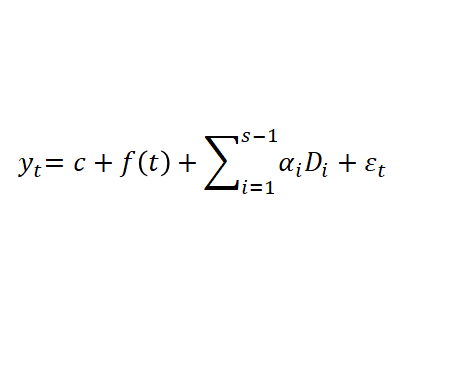

In [ ]:
Sun = pd.read_csv('data/sun.csv')
Sun['YEAR'] = pd.to_datetime(Sun['YEAR'].astype(int).astype(str) + '-01-01')
Sun.set_index("YEAR",inplace=True)

In [ ]:
x = pd.get_dummies((Sun.index.year%11).astype(str),prefix='s')

In [ ]:
ses_pred = sm.OLS(Sun.values,x.values).fit().predict(x.values)

In [ ]:
plt.plot(pd.Series(ses_pred,index=Sun.index))
plt.plot(Sun, c = 'red')
plt.legend()

In [ ]:
x = pd.get_dummies((tempsm.index.month%12).astype(str),prefix='s')

In [ ]:
plt.plot(tempsm);
plt.plot(pd.Series(sm.OLS(tempsm.values,sm.add_constant(x.values)).fit().predict(sm.add_constant(x.values)),
                   index=tempsm.index))

In [ ]:
airline = pd.read_csv('data/international-airline-passengers.csv', sep=';')
airline['Month'] = pd.to_datetime(airline['Month']+'-01')
airline.set_index('Month', inplace=True)

In [ ]:
x = pd.get_dummies((airline.index.month%12).astype(str),prefix='s')

In [ ]:
plt.plot(airline);
plt.plot(pd.Series(sm.OLS(airline.values,sm.add_constant(x.values)).fit().predict(sm.add_constant(x.values)),
                   index=airline.index))

In [ ]:
x = pd.get_dummies((airline.index.month%12).astype(str),prefix='s')
x['trend'] = airline.index.year*12 + airline.index.month

In [ ]:
plt.plot(airline);
plt.plot(pd.Series(sm.OLS(airline.values,sm.add_constant(x.values)).fit().predict(sm.add_constant(x.values)),
                   index=airline.index))

### sin и cos

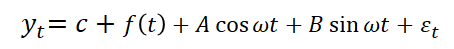

In [ ]:
x = np.c_[np.sin(2*np.pi*(Sun.index.year.values%11)/11),np.cos(2*np.pi*(Sun.index.year.values%11)/11)]

In [ ]:
ses_pred = sm.OLS(Sun.values,sm.add_constant(x)).fit().predict(sm.add_constant(x))

In [ ]:
plt.plot(pd.Series(ses_pred,index=Sun.index))
plt.plot(Sun)

In [ ]:
x = np.c_[np.sin(2*np.pi*(tempsm.index.month.values%12)/12),np.cos(2*np.pi*(tempsm.index.month.values%12)/12)]

In [ ]:
plt.plot(tempsm);
plt.plot(pd.Series(sm.OLS(tempsm.values,sm.add_constant(x)).fit().predict(sm.add_constant(x)),
                   index=tempsm.index))

## Приведение сезонного ряда к стационарному

In [ ]:
delta_determenistic = Sun.subtract(ses_pred,axis=0)
delta_stohastic = Sun - Sun.shift(11)

plt.plot(delta_determenistic,label='dummy')
plt.plot(delta_stohastic,label='stoch')
plt.legend()

Операция дифференцирования приводит ряд к стационарному, в отличии от операции десезонализации с помощью тригонометрических функций

In [ ]:
error_df = pd.DataFrame([[metr(tren)[1] for metr in stattests] for tren in [delta_determenistic,delta_stohastic.dropna()]],
            index=['dummy','stoch'],
            columns=[metr.__name__ for metr in stattests])

error_df

# Инструменты одновременного выделения тренда и сезонности

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.seasonal import STL

## Классическая декомпозиция

В классической декомпозиции тренд оценивается скользящим средним с размером окна, равному сезонности (12 для месячных данных), сезонная компонента - как среднее по каждому месяцу после вычитания тренда из исходного вр.


### Аддитивная декомпозиция

In [ ]:
fig, ax = plt.subplots(1, 1)
ax.plot(airline.index, airline['Passengers'])
ax.set_xlabel('Date')
ax.set_ylabel('Passengers');

In [ ]:
airline_add = seasonal_decompose(airline,
                                 model='additive',
                                 filt=None,
                                 period=12,
                                 two_sided=True,
                                 extrapolate_trend=1)

In [ ]:
fig = airline_add.plot();
fig.set_size_inches((12,12))

In [ ]:
airline_add.resid.plot()

мы попробовали применить к ряду аддитивную декомпозицию, но глядя на ряд остатков видно, что полностью от сезонности избавится не получилось

### Мультипликативная декомпозиция

In [ ]:
airline_mult = seasonal_decompose(airline,
                                  model='multiplicative',
                                  filt=None,
                                  period=12,
                                  two_sided=True)

In [ ]:
fig = airline_mult.plot();
fig.set_size_inches((12,12))

Для мультипликативной декомпозиции остатки выглядят гораздо лучше

In [ ]:
(airline_mult.resid-1).plot()

In [ ]:
airline_mult.resid

### Фиксируем левостороннее окно

Один из важнейших параметров для классической декомпозиции - это параметр two_sided. Если two_sided=True, то скользящее средние считается по точкам, находящимся как справа, так и слева, и только по точкам слева, если two_sided=False. В результате при two_sided=True вы гораздо лучше оценивает тренд (остатки выглядят как белый шум, но у вас остается незаполненными последние период(12)/2 = 6 значений, и для прогноза на 1 шаг вам придется экстраполировать тренд на 7 значений вперед.

In [ ]:
airline_mult_left = seasonal_decompose(airline,
                                       model='multiplicative',
                                       filt=None,
                                       period=12,
                                       two_sided=True,
                                       extrapolate_trend=1)

In [ ]:
fig = airline_mult_left.plot();
fig.set_size_inches((12,12))

In [ ]:
(airline_mult.resid-1).plot()

In [ ]:
(airline_mult_left.resid-1).plot()

In [ ]:
airline_mult_left.resid

In [ ]:
airline_mult.resid

Для двухстрононнего окна первые 6 значений и последние 6 значений не заполнены, т.к. для них недостаточно наблюдений, чтобы считать среднее

### Применение фильтров для сглаживания тренда

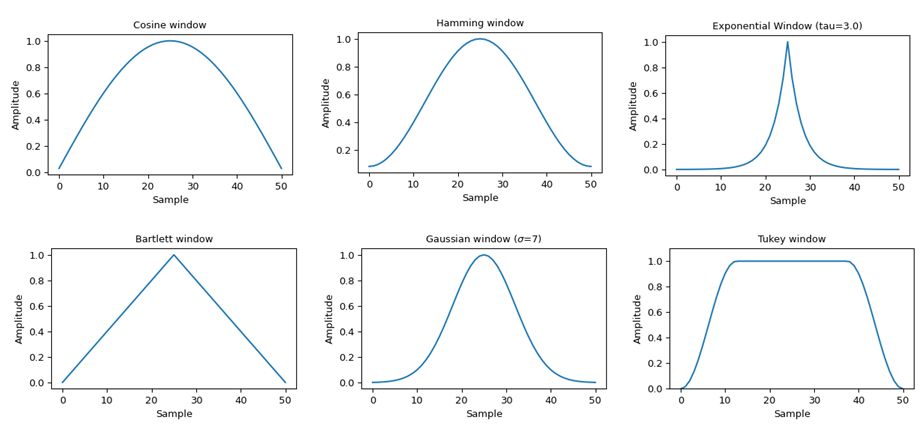

In [ ]:
from scipy.signal import windows as wind

In [ ]:
airline_mult_filt = seasonal_decompose(airline,
                                       model='multiplicative',
                                       filt=wind.bartlett(25)/np.sum(wind.bartlett(25)),
                                       period=12,
                                       two_sided=True,
                                       extrapolate_trend=0)

In [ ]:
fig = airline_mult_filt.plot();
fig.set_size_inches((12,12))

In [ ]:
airline_mult_filt.resid.plot()

In [ ]:
cur_wind = wind.bohman(23)

In [ ]:
plt.plot(cur_wind)

In [ ]:
airline_mult_filt1 = seasonal_decompose(airline,
                                       model='multiplicative',
                                       filt=cur_wind/np.sum(cur_wind),
                                       period=12,
                                       two_sided=True,
                                       extrapolate_trend=0)

In [ ]:
fig = airline_mult_filt1.plot();
fig.set_size_inches((12,12))

In [ ]:
airline_mult_filt.resid.plot()
airline_mult_filt1.resid.plot()

In [ ]:
airline_mult_filt.trend.plot()
#airline_mult_filt1.trend.plot()
airline_mult.trend.plot()

## STL-декомпозиция

### Аддитивная декомпозиция ряда

In [ ]:
airline_stl_decomp = STL(airline, period=12, seasonal_deg=1)
#airline_stl_decomp = airline_stl_decomp.fit()

Основные параметры stl: seasonal - ширина окна для усреднения сезонной компоненты (сколько точек входит для оценки сезонной компоненты), seasonal_deg - что обучаем(0 - константа, 1 - линейная), seasonal_jump - шаг линейной интерполяции (если больше 1, то обучаемся не на всех точках, а на каждой второй, третей и т.д.) 

In [ ]:
airline_stl_decomp.config

In [ ]:
airline_stl_decomp = airline_stl_decomp.fit()

In [ ]:
fig = airline_stl_decomp.plot();
fig.set_size_inches((12,12))

In [ ]:
airline_stl_decomp.resid.plot()

по сути, оценка сезонных компонент в stl - это отдельная lowess-регрессия на каждый месяц по детрендированному временному ряду.


In [ ]:
from statsmodels.nonparametric.smoothers_lowess import lowess

In [ ]:
fig,ax = plt.subplots(4,3,figsize=(25,20))
for i in range(12):
    cur_row = airline.subtract(airline_stl_decomp.trend.values,axis=0)[airline.index.month==i+1]
    x = np.array(list(range(len(cur_row))))
    ses_approx = lowess(cur_row.values.reshape(-1,),
                        x,
                        it=0,
                        frac=7/len(cur_row),return_sorted =False)
    
    ax[i//3][i%3].scatter(x, cur_row.values.reshape(-1,), c = 'red',label = 'fact')
    
    ax[i//3][i%3].plot(x,ses_approx,c='blue',label='lowess')
    
    ax[i//3][i%3].plot(x,
        cur_row.rolling(7,center=True).mean().values,c='black',label='mean5')
    
    ax[i//3][i%3].plot(x,
                       airline_stl_decomp.seasonal[airline.index.month==i+1].values,
                       c='green',label='decomp_ses')
    
    ax[i//3][i%3].legend();

### Модификация работы STL с выбросами

потестим, как работает stl на выбросах

In [ ]:
airline_corrupt = airline.copy()
airline_corrupt.loc["1954-08-01"] +=150

In [ ]:
airline_corrupt.plot()

за робастность stl отвечает параметр robust. При robust=False оценка весов для каждой точки не делается

In [ ]:
airline_corrupt_non_robust_stl_decomp = STL(airline_corrupt,period=12,robust=False).fit()

In [ ]:
fig = airline_corrupt_non_robust_stl_decomp.plot();
fig.set_size_inches((12,12))

loess реагирует на выброс (3й ряд, центральный график)

In [ ]:
fig,ax = plt.subplots(4,3,figsize=(25,20))
lowess_list = []
for i in range(12):
    cur_row = airline_corrupt.subtract(airline_corrupt_non_robust_stl_decomp.trend.values,axis=0)[airline_corrupt.index.month==i+1]
    x = np.array(list(range(len(cur_row))))
    ses_approx = lowess(cur_row.values.reshape(-1,),
                        x,
                        frac=7/len(cur_row),return_sorted =False)
    
    ax[i//3][i%3].scatter(x, cur_row.values.reshape(-1,), c = 'red',label = 'fact')
    
    ax[i//3][i%3].plot(x,ses_approx,c='blue',label='lowess')
    
    ax[i//3][i%3].plot(x,
        cur_row.rolling(5,center=True).mean().values,c='black',label='mean5')
    ax[i//3][i%3].legend();
    
    ax[i//3][i%3].plot(x,
                       airline_corrupt_non_robust_stl_decomp.seasonal[airline_corrupt.index.month==i+1].values,
                       c='green',label='decomp_ses')
    ax[i//3][i%3].legend();
    #ax[i//3][i%3].get_legend().remove()

In [ ]:
fig,ax = plt.subplots(1,1,figsize=(20,10))
cur_row = airline_corrupt.subtract(airline_corrupt_non_robust_stl_decomp.trend.values,axis=0)[airline_corrupt.index.month==8]
x = np.array(list(range(len(cur_row))))
ses_approx = lowess(cur_row.values.reshape(-1,),
                    x,
                    frac=7/len(cur_row),return_sorted =False)

ax.scatter(x, cur_row.values.reshape(-1,), c = 'red',label = 'fact')

ax.plot(x,ses_approx,c='blue',label='lowess')

ax.plot(x,cur_row.rolling(5,center=True).mean().values,c='black',label='mean5')
ax.legend();

ax.plot(x,airline_corrupt_non_robust_stl_decomp.seasonal[airline_corrupt.index.month==8].values,c='green',label='decomp_ses')

In [ ]:
airline_corrupt_robust_stl_decomp = STL(airline_corrupt,period=12,robust=True).fit()

In [ ]:
fig = airline_corrupt_robust_stl_decomp.plot();
fig.set_size_inches((12,12))

А здесь уже не реагирует

In [ ]:
fig,ax = plt.subplots(4,3,figsize=(25,20))
lowess_list = []
for i in range(12):
    cur_row = airline_corrupt.subtract(airline_corrupt_robust_stl_decomp.trend.values,axis=0)[airline_corrupt.index.month==i+1]
    x = np.array(list(range(len(cur_row))))
    ses_approx = lowess(cur_row.values.reshape(-1,),
                        x,
                        frac=7/len(cur_row),return_sorted =False)
    
    ax[i//3][i%3].scatter(x, cur_row.values.reshape(-1,), c = 'red',label = 'fact')
    
    ax[i//3][i%3].plot(x,ses_approx,c='blue',label='lowess')
    
    ax[i//3][i%3].plot(x,
        cur_row.rolling(5,center=True).mean().values,c='black',label='moving_average')
    ax[i//3][i%3].legend();
    
    ax[i//3][i%3].plot(x,
                       airline_corrupt_robust_stl_decomp.seasonal[airline_corrupt.index.month==i+1].values,
                       c='green',label='decomp_ses')
    ax[i//3][i%3].legend();
    ax[i//3][i%3].get_legend().remove()

In [ ]:
fig,ax = plt.subplots(1,1,figsize=(20,10))
cur_row = airline_corrupt.subtract(airline_corrupt_non_robust_stl_decomp.trend.values,axis=0)[airline_corrupt.index.month==8]
x = np.array(list(range(len(cur_row))))
ses_approx = lowess(cur_row.values.reshape(-1,),
                    x,
                    frac=7/len(cur_row),return_sorted =False)

ax.scatter(x, cur_row.values.reshape(-1,), c = 'red',label = 'fact')

ax.plot(x,ses_approx,c='blue',label='lowess')

ax.plot(x,cur_row.rolling(5,center=True).mean().values,c='black',label='mean5')
ax.legend();

ax.plot(x,airline_corrupt_robust_stl_decomp.seasonal[airline_corrupt.index.month==8].values,c='green',label='decomp_ses')

Сравнение весов для каждого наблюдения - для робастного и неробастного алгоритмов

In [ ]:
airline_corrupt_robust_stl_decomp.weights.plot()
airline_corrupt_non_robust_stl_decomp.weights.plot()